# BGC analysis — Biosynthetic Gene Clusters in PlantMetWiki

> ### TL;DR (map-to-rdf current release, live Virtuoso data)
> - **Triples contributed per source:** plantiSMASH = 6,030 · MIBiG = 1,813 · **total = 7,843**
> - **BGCs with NO connection to any PlantCyc pathway:** plantiSMASH 27/65 (42%) · MIBiG 37/43 (86%) · **total 64/108 (59%)**
> - These 64 "orphan" BGCs are genome-scale (plantiSMASH) or curated (MIBiG) clusters whose member genes are not yet linked to any PlantCyc pathway in `graph/pathways` — **highlighting potential targets for future pathway annotation**.

Queries BGC information from two named graphs loaded in the local Virtuoso instance.

| Graph | Source | URI |
|---|---|---|
| Core pathway RDF | PlantCyc / WikiPathways | `http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways` |
| BGC — plantiSMASH | plantiSMASH v2 (pre-calculated) | `http://rdf-plantmetwiki.bioinformatics.nl/graph/bgc-plantismash` |
| BGC — MIBiG | MIBiG (curated plant BGCs) | `http://rdf-plantmetwiki.bioinformatics.nl/graph/bgc-mibig` |

**Key vocabulary:**
- `pmw:BiosyntheticGeneCluster` — BGC instances
- `RO:0000051` (`obo:RO_0000051`, "has part") — BGC → gene member
- `wp:GeneProduct` — gene members with `identifiers.org` IRIs (used for cross-graph joins to pathway graph)
- `pmw:MemberIdentifier` — alternative gene identifiers (label only, no cross-graph IRI)

**BGC–pathway link mechanism:** Both graphs use `identifiers.org` IRIs for gene members typed as `wp:GeneProduct`. These same IRIs are used in the core pathway graph (`G_PW`) as gene/protein DataNode subjects with `dcterms:isPartOf pathway`. This shared IRI space is the join key for all cross-graph queries.

**Pathway identifiers:** All `pw_id` values shown in this notebook are PlantCyc stable accession IDs (e.g. `PWY-5936`), sourced from `graph/gpml-properties-extra`. Internal sequential IDs (e.g. `PC721`) used internally by the RDF conversion pipeline are not shown.

**Kernel:** `plantmetwiki-rdf`

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

ENDPOINT = "http://localhost:8890/sparql"

BASE      = "http://rdf-plantmetwiki.bioinformatics.nl"
G_PW      = f"{BASE}/graph/pathways"
G_PS      = f"{BASE}/graph/bgc-plantismash"
G_MIB     = f"{BASE}/graph/bgc-mibig"
G_PROPS   = f"{BASE}/graph/gpml-properties-extra"

PMW       = f"{BASE}/vocab/"
BGC_TYPE  = f"{PMW}BiosyntheticGeneCluster"
MEM_ID    = f"{PMW}MemberIdentifier"
RO_PART   = "http://purl.obolibrary.org/obo/RO_0000051"
WP_GENE   = "http://vocabularies.wikipathways.org/wp#GeneProduct"
WP_ORG    = "http://vocabularies.wikipathways.org/wp#organism"
WP_ORGN   = "http://vocabularies.wikipathways.org/wp#organismName"
DC_TITLE  = "http://purl.org/dc/elements/1.1/title"
DC_IPART  = "http://purl.org/dc/terms/isPartOf"
WP_PW     = "http://vocabularies.wikipathways.org/wp#Pathway"

PREFIXES = """
PREFIX wp:      <http://vocabularies.wikipathways.org/wp#>
PREFIX pmw:     <http://rdf-plantmetwiki.bioinformatics.nl/vocab/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX dc:      <http://purl.org/dc/elements/1.1/>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>
PREFIX rdf:     <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX obo:     <http://purl.obolibrary.org/obo/>
PREFIX foaf:    <http://xmlns.com/foaf/0.1/>
"""

def run_query(query: str, timeout: int = 120) -> pd.DataFrame:
    sp = SPARQLWrapper(ENDPOINT)
    sp.setQuery(PREFIXES + query)
    sp.setReturnFormat(JSON)
    sp.setTimeout(timeout)
    rows = sp.query().convert()["results"]["bindings"]
    if not rows:
        return pd.DataFrame()
    cols = list(rows[0].keys())
    return pd.DataFrame(
        [{c: r[c]["value"] for c in cols if c in r} for r in rows],
        columns=cols,
    )

print(f"Endpoint : {ENDPOINT}")
print("Ready.")

Endpoint : http://localhost:8890/sparql
Ready.


---
## 1. Named graph sizes

How many triples do the two BGC graphs contribute?

In [2]:
run_query(f"""
SELECT ?graph (COUNT(*) AS ?triples)
WHERE {{
  VALUES ?graph {{ <{G_PS}> <{G_MIB}> }}
  GRAPH ?graph {{ ?s ?p ?o }}
}}
GROUP BY ?graph
ORDER BY ?graph
""")

,graph,triples
0,http://rdf-plantmetwiki.bioinformatics.nl/grap...,1770
1,http://rdf-plantmetwiki.bioinformatics.nl/grap...,5965


---
## 2. BGC inventory by source

How many BGCs are in each source, and which species do they cover?

In [3]:
# Total BGCs per graph
for label, graph in [("plantiSMASH", G_PS), ("MIBiG", G_MIB)]:
    df = run_query(f"""
    SELECT (COUNT(DISTINCT ?bgc) AS ?n_bgcs)
    WHERE {{
      GRAPH <{graph}> {{ ?bgc a pmw:BiosyntheticGeneCluster }}
    }}
    """)
    print(f"{label}: {df['n_bgcs'].iloc[0]} BGCs")

plantiSMASH: 65 BGCs
MIBiG: 43 BGCs


In [4]:
# plantiSMASH — BGC and gene counts per species
print("plantiSMASH — species breakdown")
display(run_query(f"""
SELECT ?organism (COUNT(DISTINCT ?bgc) AS ?n_bgcs) (COUNT(DISTINCT ?gene) AS ?n_genes)
WHERE {{
  GRAPH <{G_PS}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ;
         wp:organismName ?organism ;
         <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
  }}
}}
GROUP BY ?organism
ORDER BY DESC(?n_bgcs)
"""))

print()
print("MIBiG — species breakdown (only BGCs with wp:GeneProduct members shown)")
display(run_query(f"""
SELECT ?organism (COUNT(DISTINCT ?bgc) AS ?n_bgcs) (COUNT(DISTINCT ?gene) AS ?n_genes)
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ;
         <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
    OPTIONAL {{ ?bgc wp:organismName ?organism . }}
  }}
}}
GROUP BY ?organism
ORDER BY DESC(?n_bgcs)
"""))

print()
print("MIBiG — all 43 BGCs, by presence of an organism annotation")
display(run_query(f"""
SELECT (BOUND(?organism) AS ?has_organism) (COUNT(DISTINCT ?bgc) AS ?n_bgcs)
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster .
    OPTIONAL {{ ?bgc wp:organismName ?organism . }}
  }}
}}
GROUP BY (BOUND(?organism))
"""))


plantiSMASH — species breakdown


,organism,n_bgcs,n_genes
0,Arabidopsis thaliana,65,940



MIBiG — species breakdown (only BGCs with wp:GeneProduct members shown)


,organism,n_bgcs,n_genes
0,Arabidopsis thaliana,9,69



MIBiG — all 43 BGCs, by presence of an organism annotation


,has_organism,n_bgcs
0,0,34
1,1,9


---
## 3. Gene members

BGC members come in two flavours:
- `wp:GeneProduct` — typed with `identifiers.org` IRIs, used for cross-graph joins
- `pmw:MemberIdentifier` — label-only nodes (no `identifiers.org` IRI), used for display

How many unique gene members of each type per source?

In [5]:
# Gene member type counts per graph
run_query(f"""
SELECT ?source ?member_type (COUNT(DISTINCT ?member) AS ?n)
WHERE {{
  {{
    GRAPH <{G_PS}> {{
      ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?member .
      ?member a ?member_type .
    }}
    BIND("plantiSMASH" AS ?source)
  }}
  UNION
  {{
    GRAPH <{G_MIB}> {{
      ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?member .
      ?member a ?member_type .
    }}
    BIND("MIBiG" AS ?source)
  }}
  FILTER(?member_type IN (wp:GeneProduct, pmw:MemberIdentifier))
}}
GROUP BY ?source ?member_type
ORDER BY ?source ?member_type
""")

,source,member_type,n
0,MIBiG,http://rdf-plantmetwiki.bioinformatics.nl/voca...,403
1,MIBiG,http://vocabularies.wikipathways.org/wp#GenePr...,69
2,plantiSMASH,http://vocabularies.wikipathways.org/wp#GenePr...,940


In [6]:
# Unique wp:GeneProduct members per graph, and overlap between the two
def count_geneproducts(graph):
    df = run_query(f"""
    SELECT (COUNT(DISTINCT ?gene) AS ?n)
    WHERE {{
      GRAPH <{graph}> {{ ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene . ?gene a wp:GeneProduct . }}
    }}
    """)
    return int(df["n"].iloc[0])

n_ps  = count_geneproducts(G_PS)
n_mib = count_geneproducts(G_MIB)

df_overlap = run_query(f"""
SELECT (COUNT(DISTINCT ?gene) AS ?n_overlap)
WHERE {{
  GRAPH <{G_PS}>  {{ ?bgc1 a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene . ?gene a wp:GeneProduct . }}
  GRAPH <{G_MIB}> {{ ?bgc2 a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene . ?gene a wp:GeneProduct . }}
}}
""")
n_both = int(df_overlap["n_overlap"].iloc[0])

print(f"plantiSMASH unique GeneProduct members : {n_ps}")
print(f"MIBiG unique GeneProduct members       : {n_mib}")
print(f"Shared between both graphs             : {n_both}")
print(f"Total unique across both sources       : {n_ps + n_mib - n_both}")


plantiSMASH unique GeneProduct members : 940
MIBiG unique GeneProduct members       : 69
Shared between both graphs             : 43
Total unique across both sources       : 966


---
## 4. BGC–pathway gene links

A **BGC–pathway gene link** is a unique `(BGC, gene, pathway)` triple where:
1. `bgc obo:RO_0000051 gene` (in a BGC graph) — BGC contains this gene
2. `gene dcterms:isPartOf pathway` (in the pathway graph) — gene participates in this pathway

The join key is the shared `identifiers.org` IRI used by both the BGC and pathway graphs for the same gene.

How many unique BGC–pathway gene links exist?

In [7]:
# BGC-pathway gene links per source
for label, graph in [("plantiSMASH", G_PS), ("MIBiG", G_MIB)]:
    df = run_query(f"""
    SELECT
      (COUNT(DISTINCT ?bgc_pw) AS ?bgc_pathway_pairs)
      (COUNT(DISTINCT ?link)   AS ?bgc_gene_pw_triples)
      (COUNT(DISTINCT ?gene)   AS ?unique_genes)
      (COUNT(DISTINCT ?bgc)    AS ?bgcs_connected)
      (COUNT(DISTINCT ?pw)     AS ?pathways_touched)
    WHERE {{
      GRAPH <{graph}> {{
        ?bgc a pmw:BiosyntheticGeneCluster ;
             <{RO_PART}> ?gene .
        ?gene a wp:GeneProduct .
      }}
      GRAPH <{G_PW}> {{
        ?gene dcterms:isPartOf ?pw .
        ?pw a wp:Pathway .
      }}
      BIND(CONCAT(STR(?bgc), "|", STR(?pw)) AS ?bgc_pw)
      BIND(CONCAT(STR(?bgc), "|", STR(?gene), "|", STR(?pw)) AS ?link)
    }}
    """, timeout=180)
    print(f"{label}:")
    display(df)

plantiSMASH:


,bgc_pathway_pairs,bgc_gene_pw_triples,unique_genes,bgcs_connected,pathways_touched
0,189,206,57,38,131


MIBiG:


,bgc_pathway_pairs,bgc_gene_pw_triples,unique_genes,bgcs_connected,pathways_touched
0,17,19,9,6,11


In [8]:
# Combined: unique (BGC, gene) pairs that bridge to at least one pathway
df_ps_links = run_query(f"""
SELECT DISTINCT ?bgc ?gene
WHERE {{
  GRAPH <{G_PS}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
  }}
  GRAPH <{G_PW}> {{ ?gene dcterms:isPartOf ?pw . }}
}}
""", timeout=180)

df_mib_links = run_query(f"""
SELECT DISTINCT ?bgc ?gene
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
  }}
  GRAPH <{G_PW}> {{ ?gene dcterms:isPartOf ?pw . }}
}}
""", timeout=180)

combined = pd.concat([df_ps_links, df_mib_links], ignore_index=True).drop_duplicates()
print(f"Unique (BGC, gene) pairs bridging BGC and pathway graphs: {len(combined)}")
print(f"  plantiSMASH pairs : {len(df_ps_links)}")
print(f"  MIBiG pairs       : {len(df_mib_links)}")

Unique (BGC, gene) pairs bridging BGC and pathway graphs: 66
  plantiSMASH pairs : 57
  MIBiG pairs       : 9


---
## 4b. Documenting the BGC–pathway crosslinks (Supplementary Table S3)

The table built below lists every individual **(BGC, gene, pathway)** crosslink — i.e. each row is one
`wp:GeneProduct` that is *both*:

1. a member of a Biosynthetic Gene Cluster (`pmw:BiosyntheticGeneCluster` —`obo:RO_0000051`("has part")→ gene), **and**
2. part of a PlantCyc pathway (gene —`dcterms:isPartOf`→ `wp:Pathway`).

This is the **"Supplementary Table S3"** referenced in the pipeline summaries, exported here as
`figures/output/bgc_pathway_links_full.csv`.

> **Note on versioning:** the static `map-to-rdf/summaries/bgc_pathway_links.tsv` file (199 links / 38 BGCs /
> 50 genes / 109 pathways) was generated against an earlier `graph/pathways` snapshot. Both BGC graphs
> (`bgc-v1.1`) are unchanged since then — the live numbers below (225 links / 44 BGCs / 58 genes / 132 pathways)
> are slightly higher only because the `graph/pathways` snapshot currently loaded in Virtuoso is newer and
> covers more pathway↔gene `dcterms:isPartOf` relations. Re-run this notebook after any `graph/pathways`
> reload to keep the table in sync.


In [9]:
from pathlib import Path

OUT_DIR = Path('figures/output')
FIG_DIR = Path('figures/output/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Full (BGC, gene, pathway) crosslink table with human-readable labels.
# pw_id comes from graph/gpml-properties-extra (dcterms:identifier = PlantCyc PWY/RXN accession,
# e.g. "PWY-5936"), not from graph/pathways (which stores internal sequential IDs like "PC721").
def link_query(graph, source):
    df = run_query(f"""
    SELECT ?bgc ?bgc_label ?gene ?pw ?pw_id ?pw_title
    WHERE {{
      GRAPH <{graph}> {{
        ?bgc a pmw:BiosyntheticGeneCluster ; rdfs:label ?bgc_label ; <{RO_PART}> ?gene .
        ?gene a wp:GeneProduct .
      }}
      GRAPH <{G_PW}> {{
        ?gene dcterms:isPartOf ?pw .
        ?pw a wp:Pathway ; dc:title ?pw_title .
      }}
      GRAPH <{G_PROPS}> {{ ?pw dcterms:identifier ?pw_id . }}
    }}
    """, timeout=180)
    df["source"] = source
    return df

df_links = pd.concat([link_query(G_PS, "plantiSMASH"), link_query(G_MIB, "MIBiG")], ignore_index=True)
df_links["gene_id"] = df_links["gene"].str.rsplit("/", n=1).str[-1]

print(f"Supplementary Table S3 - {len(df_links)} (BGC, gene, pathway) crosslinks")
print(f"  Unique BGCs     : {df_links['bgc'].nunique()}")
print(f"  Unique genes    : {df_links['gene_id'].nunique()}")
print(f"  Unique pathways : {df_links['pw_id'].nunique()}")

df_links[["source", "bgc_label", "gene_id", "pw_id", "pw_title"]].to_csv(
    OUT_DIR / "bgc_pathway_links_full.csv", index=False
)
print(f"\nSaved: {OUT_DIR / 'bgc_pathway_links_full.csv'}")

df_links[["source", "bgc_label", "gene_id", "pw_id", "pw_title"]].head(10)

Supplementary Table S3 - 225 (BGC, gene, pathway) crosslinks
  Unique BGCs     : 44
  Unique genes    : 58
  Unique pathways : 132

Saved: figures/output/bgc_pathway_links_full.csv


,source,bgc_label,gene_id,pw_id,pw_title
0,plantiSMASH,#cluster-12,AT1G62960,PWY-7117,"C4 photosynthetic carbon assimilation cycle, P..."
1,plantiSMASH,#cluster-11,AT1G62800,PWY-7117,"C4 photosynthetic carbon assimilation cycle, P..."
2,plantiSMASH,#cluster-12,AT1G62960,PWY-5079,L-phenylalanine degradation III
3,plantiSMASH,#cluster-24,AT2G29740,PWY-7157,eupatolitin 3-O-glucoside biosynthesis
4,plantiSMASH,#cluster-24,AT2G29750,PWY-7157,eupatolitin 3-O-glucoside biosynthesis
5,plantiSMASH,#cluster-10,AT1G60440,PANTO-PWY,phosphopantothenate biosynthesis I
6,plantiSMASH,#cluster-4,AT1G24100,PWY-1187,glucosinolate biosynthesis from homomethionine
7,plantiSMASH,#cluster-14,AT1G65860,PWY-1187,glucosinolate biosynthesis from homomethionine
8,plantiSMASH,#cluster-16,AT1G73370,PWY-3801,sucrose degradation II (sucrose synthase)
9,plantiSMASH,#cluster-57,AT5G42600,PWY-6005,marneral biosynthesis


---
## 5. BGCs with no PlantCyc pathway connection

BGCs that have no gene member shared with any PlantCyc pathway.
These are clusters where the gene annotation (`identifiers.org` IRIs typed as `wp:GeneProduct`) does not
overlap with current PlantMetWiki pathway coverage. As noted in the TL;DR above, **64/108 (59%) of all
BGCs** fall into this category — these are prime candidates for future pathway annotation work.


In [10]:
# BGCs WITH at least one pathway connection
for label, graph, total in [("plantiSMASH", G_PS, 65), ("MIBiG", G_MIB, 43)]:
    df = run_query(f"""
    SELECT (COUNT(DISTINCT ?bgc) AS ?n_connected)
    WHERE {{
      GRAPH <{graph}> {{
        ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene .
        ?gene a wp:GeneProduct .
      }}
      GRAPH <{G_PW}> {{ ?gene dcterms:isPartOf ?pw . ?pw a wp:Pathway . }}
    }}
    """, timeout=180)
    n_conn = int(df["n_connected"].iloc[0])
    n_not  = total - n_conn
    print(f"{label}: {n_conn}/{total} ({100*n_conn/total:.0f}%) BGCs connect to a pathway")
    print(f"         {n_not}/{total} ({100*n_not/total:.0f}%) BGCs have NO pathway connection")
    print()


plantiSMASH: 38/65 (58%) BGCs connect to a pathway
         27/65 (42%) BGCs have NO pathway connection

MIBiG: 6/43 (14%) BGCs connect to a pathway
         37/43 (86%) BGCs have NO pathway connection



**Which MIBiG BGCs are not captured?**

The 37/43 MIBiG BGCs above with no shared gene with any PlantCyc pathway, listed by their `rdfs:label`
(`mibig:BGC*` accession).


In [11]:
# MIBiG BGCs with NO PlantCyc pathway connection (the 37/43 from above)
df_mib_uncaptured = run_query(f"""
SELECT ?bgc_label
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; rdfs:label ?bgc_label .
    FILTER NOT EXISTS {{
      ?bgc <{RO_PART}> ?gene .
      ?gene a wp:GeneProduct .
      GRAPH <{G_PW}> {{ ?gene dcterms:isPartOf ?pw . ?pw a wp:Pathway . }}
    }}
  }}
}}
ORDER BY ?bgc_label
""", timeout=180)

# A. thaliana-annotated MIBiG BGCs (separate query: organismName is mandatory here,
# avoiding the OPTIONAL-var-binding pitfall in run_query() when the first row lacks it)
df_mib_athaliana = run_query(f"""
SELECT ?bgc_label
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; rdfs:label ?bgc_label ; wp:organismName "Arabidopsis thaliana" .
  }}
}}
""")

df_mib_uncaptured["is_A_thaliana"] = df_mib_uncaptured["bgc_label"].isin(set(df_mib_athaliana["bgc_label"]))

n_athaliana = int(df_mib_uncaptured["is_A_thaliana"].sum())
print(f"MIBiG BGCs with NO PlantCyc pathway connection: {len(df_mib_uncaptured)}/43")
print(f"  {n_athaliana} of these are annotated as Arabidopsis thaliana:")
display(df_mib_uncaptured[df_mib_uncaptured["is_A_thaliana"]])

print(f"\nFull list of {len(df_mib_uncaptured)} uncaptured MIBiG BGCs:")
df_mib_uncaptured


MIBiG BGCs with NO PlantCyc pathway connection: 37/43
  3 of these are annotated as Arabidopsis thaliana:


,bgc_label,is_A_thaliana
4,mibig:BGC0001314,True
13,mibig:BGC0001756,True
23,mibig:BGC0002401,True



Full list of 37 uncaptured MIBiG BGCs:


,bgc_label,is_A_thaliana
0,mibig:BGC0000671,False
1,mibig:BGC0000672,False
2,mibig:BGC0000798,False
3,mibig:BGC0000810,False
4,mibig:BGC0001314,True
5,mibig:BGC0001315,False
6,mibig:BGC0001316,False
7,mibig:BGC0001317,False
8,mibig:BGC0001318,False
9,mibig:BGC0001321,False


---
## 6. Top connected pathways

Which PlantCyc pathways are linked to the most BGC genes?

In [12]:
# plantiSMASH — top pathways by unique gene count
# pw_id from graph/gpml-properties-extra = PlantCyc PWY/RXN accession
print("plantiSMASH — top 20 pathways with most BGC gene links")
display(run_query(f"""
SELECT ?pw_id ?title
       (COUNT(DISTINCT ?bgc)  AS ?n_bgcs)
       (COUNT(DISTINCT ?gene) AS ?n_genes)
WHERE {{
  GRAPH <{G_PS}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
  }}
  GRAPH <{G_PW}> {{
    ?gene dcterms:isPartOf ?pw .
    ?pw a wp:Pathway ; dc:title ?title .
  }}
  GRAPH <{G_PROPS}> {{ ?pw dcterms:identifier ?pw_id . }}
}}
GROUP BY ?pw_id ?title
ORDER BY DESC(?n_genes) DESC(?n_bgcs)
LIMIT 20
""", timeout=180))

plantiSMASH — top 20 pathways with most BGC gene links


,pw_id,title,n_bgcs,n_genes
0,PWY-7129,quercetin glucoside biosynthesis (Allium),3,5
1,PWY-5321,quercetin glycoside biosynthesis (Arabidopsis),3,5
2,PWY-6266,superpathway of flavones and derivatives biosy...,3,5
3,PWY-6266-ARA,superpathway of flavones and derivatives biosy...,3,5
4,PWY-5863,superpathway of phylloquinol biosynthesis,4,4
5,PWY-7137,quercetin gentiotetraside biosynthesis,3,4
6,PWY-7172,flavonol acylglucoside biosynthesis III-querce...,3,4
7,PWY-7173,quercetin triglucoside biosynthesis,3,4
8,PWY-5390,rutin biosynthesis,3,4
9,PWY-6360,flavonol glucosylation I,3,4


In [13]:
# MIBiG — all connected pathways
# pw_id from graph/gpml-properties-extra = PlantCyc PWY/RXN accession
print("MIBiG — pathways with BGC gene links")
display(run_query(f"""
SELECT ?pw_id ?title
       (COUNT(DISTINCT ?bgc)  AS ?n_bgcs)
       (COUNT(DISTINCT ?gene) AS ?n_genes)
WHERE {{
  GRAPH <{G_MIB}> {{
    ?bgc a pmw:BiosyntheticGeneCluster ; <{RO_PART}> ?gene .
    ?gene a wp:GeneProduct .
  }}
  GRAPH <{G_PW}> {{
    ?gene dcterms:isPartOf ?pw .
    ?pw a wp:Pathway ; dc:title ?title .
  }}
  GRAPH <{G_PROPS}> {{ ?pw dcterms:identifier ?pw_id . }}
}}
GROUP BY ?pw_id ?title
ORDER BY DESC(?n_genes)
""", timeout=180))

MIBiG — pathways with BGC gene links


,pw_id,title,n_bgcs,n_genes
0,PWY-5992,thalianol and derivatives biosynthesis,1,3
1,PWY-5121,superpathway of geranylgeranyl pyrophosphate b...,2,2
2,PWY-5910,superpathway of geranylgeranylpyrophosphate bi...,2,2
3,PWY-5120,geranylgeranyl pyrophosphate biosynthesis,2,2
4,PWY-6691,plaunotol biosynthesis,2,2
5,PWY-7392,taxadiene biosynthesis (engineered),2,2
6,PWY-5863,superpathway of phylloquinol biosynthesis,2,2
7,PWY-6008,baruol biosynthesis,1,1
8,PWY-6007,"(3E)-4,8-dimethylnona-1,3,7-triene biosynthesi...",1,1
9,RXN-15011,RXN-15011,1,1


---
## 7. Visualizations

Three complementary views of the BGC–pathway crosslink data in `df_links` (Supplementary Table S3):

1. **Gene-level overlap (Venn diagram)** — how much do plantiSMASH, MIBiG, and PlantCyc-pathway gene sets
   overlap, at the level of `wp:GeneProduct` `identifiers.org` IRIs?
2. **Pathway × BGC matrix** — for the most-connected pathways, how many genes does each connected BGC
   contribute?
3. **Network view of the top-connected pathway** — a worked example of the underlying RDF model
   (`pmw:BiosyntheticGeneCluster` —`obo:RO_0000051`("has part")→ `wp:GeneProduct` —`dcterms:isPartOf`→
   `wp:Pathway`), showing how plantiSMASH and MIBiG BGCs converge on shared pathway genes.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn3
import networkx as nx
import textwrap


### 7.1 Gene-level overlap — plantiSMASH vs MIBiG vs PlantCyc pathways


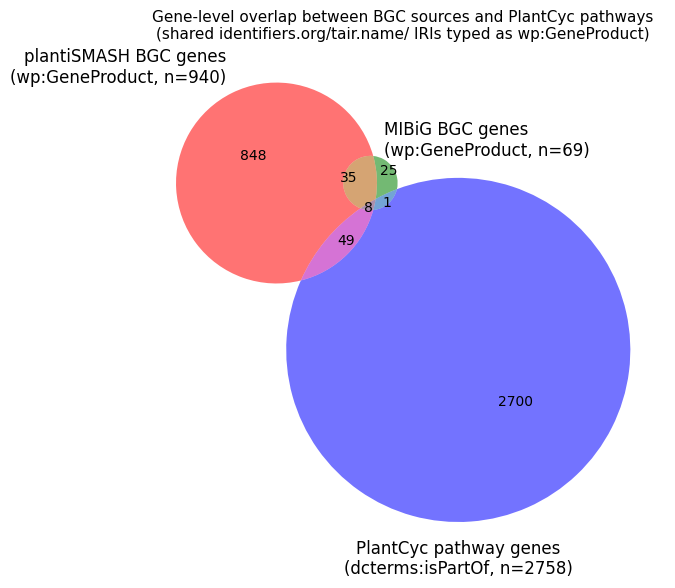

plantiSMASH only                       : 848
MIBiG only                              : 25
plantiSMASH ∩ MIBiG (excl. PlantCyc)    : 35
PlantCyc only                          : 2700
plantiSMASH ∩ PlantCyc (excl. MIBiG)    : 49
MIBiG ∩ PlantCyc (excl. plantiSMASH)    : 1
plantiSMASH ∩ MIBiG ∩ PlantCyc          : 8


In [15]:
# Gene sets (wp:GeneProduct identifiers.org IRIs)
def gene_set(query):
    df = run_query(query, timeout=180)
    return set(df["gene"]) if not df.empty else set()

set_ps = gene_set(f"""
SELECT DISTINCT ?gene WHERE {{ GRAPH <{G_PS}> {{ ?bgc <{RO_PART}> ?gene . ?gene a wp:GeneProduct . }} }}
""")
set_mib = gene_set(f"""
SELECT DISTINCT ?gene WHERE {{ GRAPH <{G_MIB}> {{ ?bgc <{RO_PART}> ?gene . ?gene a wp:GeneProduct . }} }}
""")
set_pw = gene_set(f"""
SELECT DISTINCT ?gene WHERE {{ GRAPH <{G_PW}> {{ ?gene dcterms:isPartOf ?pw . ?pw a wp:Pathway . ?gene a wp:GeneProduct . }} }}
""")

# venn3 subset order: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
subsets = (
    len(set_ps - set_mib - set_pw),
    len(set_mib - set_ps - set_pw),
    len((set_ps & set_mib) - set_pw),
    len(set_pw - set_ps - set_mib),
    len((set_ps & set_pw) - set_mib),
    len((set_mib & set_pw) - set_ps),
    len(set_ps & set_mib & set_pw),
)

fig, ax = plt.subplots(figsize=(7, 6))
v = venn3(
    subsets=subsets,
    set_labels=(
        f"plantiSMASH BGC genes\n(wp:GeneProduct, n={len(set_ps)})",
        f"MIBiG BGC genes\n(wp:GeneProduct, n={len(set_mib)})",
        f"PlantCyc pathway genes\n(dcterms:isPartOf, n={len(set_pw)})",
    ),
    ax=ax,
)
for patch in v.patches:
    if patch:
        patch.set_alpha(0.55)
ax.set_title(
    "Gene-level overlap between BGC sources and PlantCyc pathways\n"
    "(shared identifiers.org/tair.name/ IRIs typed as wp:GeneProduct)",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "bgc_pathway_gene_venn.pdf")
fig.savefig(FIG_DIR / "bgc_pathway_gene_venn.svg")
plt.show()

print(f"plantiSMASH only                       : {subsets[0]}")
print(f"MIBiG only                              : {subsets[1]}")
print(f"plantiSMASH \u2229 MIBiG (excl. PlantCyc)    : {subsets[2]}")
print(f"PlantCyc only                          : {subsets[3]}")
print(f"plantiSMASH \u2229 PlantCyc (excl. MIBiG)    : {subsets[4]}")
print(f"MIBiG \u2229 PlantCyc (excl. plantiSMASH)    : {subsets[5]}")
print(f"plantiSMASH \u2229 MIBiG \u2229 PlantCyc          : {subsets[6]}")


In [16]:
from IPython.display import Markdown
n_ps_pw  = subsets[4] + subsets[6]   # plantiSMASH ∩ PlantCyc (with or without MIBiG)
n_mib_pw = subsets[5] + subsets[6]   # MIBiG ∩ PlantCyc (with or without plantiSMASH)
display(Markdown(
    f"**Figure 7.1.** Gene-level overlap between Biosynthetic Gene Cluster (BGC) sources and "
    f"PlantCyc pathway annotations in PlantMetWiki. Sets represent all `wp:GeneProduct` gene members "
    f"identified by `identifiers.org/tair.locus` IRIs: plantiSMASH BGC genes (*n* = {len(set_ps)}), "
    f"MIBiG BGC genes (*n* = {len(set_mib)}), and PlantCyc pathway genes (*n* = {len(set_pw):,}; all "
    f"genes with `dcterms:isPartOf` a `wp:Pathway` in `graph/pathways`). "
    f"Only `wp:GeneProduct` nodes (with `identifiers.org` IRIs) can form cross-graph joins; "
    f"`pmw:MemberIdentifier` nodes (403 in MIBiG, 0 in plantiSMASH) are excluded. "
    f"Of the {len(set_ps)} plantiSMASH BGC genes, {n_ps_pw} ({100*n_ps_pw/len(set_ps):.0f}%) overlap "
    f"with at least one PlantCyc pathway gene; for MIBiG, {n_mib_pw} of {len(set_mib)} "
    f"({100*n_mib_pw/len(set_mib):.0f}%). "
    f"{subsets[2]} genes are shared between plantiSMASH and MIBiG BGC graphs but absent from any "
    f"current PlantCyc pathway."
))

**Figure 7.1.** Gene-level overlap between Biosynthetic Gene Cluster (BGC) sources and PlantCyc pathway annotations in PlantMetWiki. Sets represent all `wp:GeneProduct` gene members identified by `identifiers.org/tair.locus` IRIs: plantiSMASH BGC genes (*n* = 940), MIBiG BGC genes (*n* = 69), and PlantCyc pathway genes (*n* = 2,758; all genes with `dcterms:isPartOf` a `wp:Pathway` in `graph/pathways`). Only `wp:GeneProduct` nodes (with `identifiers.org` IRIs) can form cross-graph joins; `pmw:MemberIdentifier` nodes (403 in MIBiG, 0 in plantiSMASH) are excluded. Of the 940 plantiSMASH BGC genes, 57 (6%) overlap with at least one PlantCyc pathway gene; for MIBiG, 9 of 69 (13%). 35 genes are shared between plantiSMASH and MIBiG BGC graphs but absent from any current PlantCyc pathway.

### 7.2 Pathway × BGC matrix — shared genes per pathway


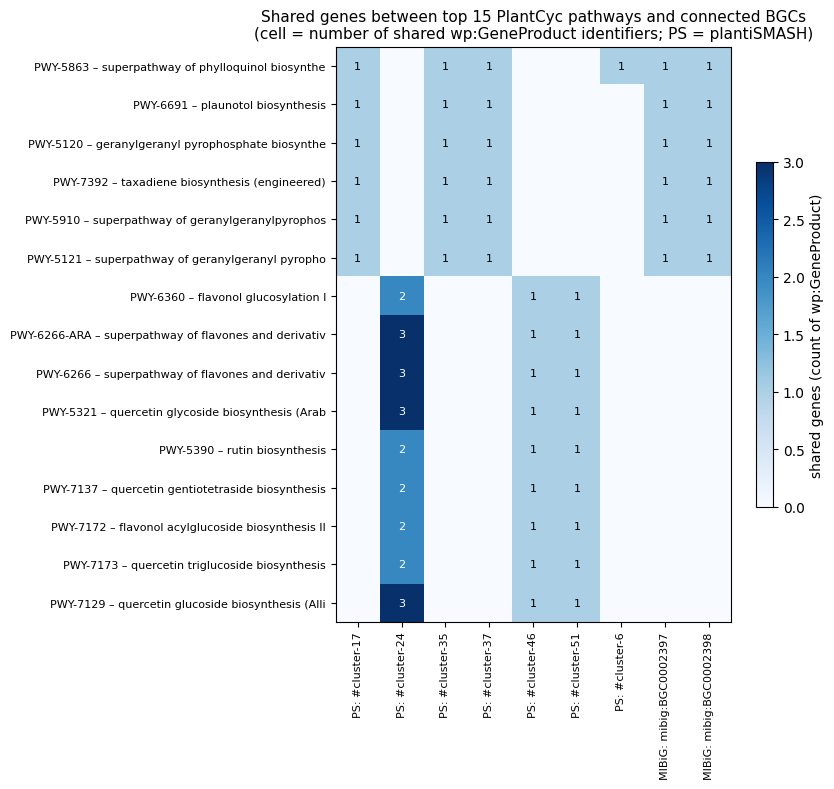

Saved matrix data: figures/output/bgc_pathway_matrix.csv  (206 rows)

Top pathways by number of connected BGCs:


,pw_id,pw_title,n_bgcs
0,PWY-5863,superpathway of phylloquinol biosynthesis,6
1,PWY-6691,plaunotol biosynthesis,5
2,PWY-5120,geranylgeranyl pyrophosphate biosynthesis,5
3,PWY-7392,taxadiene biosynthesis (engineered),5
4,PWY-5910,superpathway of geranylgeranylpyrophosphate bi...,5
5,PWY-5121,superpathway of geranylgeranyl pyrophosphate b...,5
6,PWY-6360,flavonol glucosylation I,3
7,PWY-6266-ARA,superpathway of flavones and derivatives biosy...,3
8,PWY-6266,superpathway of flavones and derivatives biosy...,3
9,PWY-5321,quercetin glycoside biosynthesis (Arabidopsis),3


In [17]:
# Matrix: for each (pathway, BGC) pair, how many genes are shared?
matrix = (df_links.groupby(["pw_id", "pw_title", "bgc_label", "source"])["gene_id"]
          .nunique().reset_index(name="n_genes"))

top_pw = (matrix.groupby(["pw_id", "pw_title"])["bgc_label"]
          .nunique().sort_values(ascending=False))
top_pw_df = top_pw.head(15).reset_index(name="n_bgcs")

sub = matrix[matrix["pw_id"].isin(top_pw_df["pw_id"])].copy()
src_prefix = {"plantiSMASH": "PS", "MIBiG": "MIBiG"}
sub["bgc_disp"] = sub["source"].map(src_prefix) + ": " + sub["bgc_label"]

pivot = sub.pivot_table(index="pw_id", columns="bgc_disp", values="n_genes", fill_value=0)
pivot = pivot.loc[top_pw_df["pw_id"]]
cols_sorted = sorted(pivot.columns, key=lambda c: (not c.startswith("PS"), c))
pivot = pivot[cols_sorted]

title_map = dict(zip(top_pw_df["pw_id"], top_pw_df["pw_title"]))
row_labels = [f"{pid} \u2013 {title_map[pid][:38]}" for pid in pivot.index]

fig, ax = plt.subplots(figsize=(0.5 * len(pivot.columns) + 4, 0.4 * len(pivot) + 2))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(row_labels, fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v_ij = pivot.values[i, j]
        if v_ij > 0:
            ax.text(j, i, int(v_ij), ha="center", va="center", fontsize=8,
                    color="white" if v_ij > pivot.values.max() / 2 else "black")
ax.set_title(
    f"Shared genes between top {len(top_pw_df)} PlantCyc pathways and connected BGCs\n"
    "(cell = number of shared wp:GeneProduct identifiers; PS = plantiSMASH)",
    fontsize=11,
)
fig.colorbar(im, ax=ax, label="shared genes (count of wp:GeneProduct)", shrink=0.6)
fig.tight_layout()
fig.savefig(FIG_DIR / "bgc_pathway_matrix.pdf")
fig.savefig(FIG_DIR / "bgc_pathway_matrix.svg")
plt.show()

matrix.to_csv(OUT_DIR / "bgc_pathway_matrix.csv", index=False)
print(f"Saved matrix data: {OUT_DIR / 'bgc_pathway_matrix.csv'}  ({len(matrix)} rows)")
print("\nTop pathways by number of connected BGCs:")
top_pw_df


In [18]:
display(Markdown(
    f"**Figure 7.2.** Gene-sharing matrix between the top {len(top_pw_df)} PlantCyc pathways "
    f"(ranked by number of connected BGCs) and individual Biosynthetic Gene Clusters from "
    f"plantiSMASH (PS:) and MIBiG. Rows are PlantCyc pathways labelled by their stable accession "
    f"(PWY/RXN ID from `graph/gpml-properties-extra`) and title (truncated to 38 characters). "
    f"Columns are individual BGC labels. Cell values show the count of shared `wp:GeneProduct` "
    f"IRIs (`identifiers.org/tair.locus`) between a pathway and a BGC; empty cells indicate no "
    f"shared gene. Full crosslink data (all {len(df_links)} BGC–gene–pathway triples) in "
    f"Supplementary Table S3 (`bgc_pathway_links_full.csv`). Matrix data exported to "
    f"`bgc_pathway_matrix.csv`."
))

**Figure 7.2.** Gene-sharing matrix between the top 15 PlantCyc pathways (ranked by number of connected BGCs) and individual Biosynthetic Gene Clusters from plantiSMASH (PS:) and MIBiG. Rows are PlantCyc pathways labelled by their stable accession (PWY/RXN ID from `graph/gpml-properties-extra`) and title (truncated to 38 characters). Columns are individual BGC labels. Cell values show the count of shared `wp:GeneProduct` IRIs (`identifiers.org/tair.locus`) between a pathway and a BGC; empty cells indicate no shared gene. Full crosslink data (all 225 BGC–gene–pathway triples) in Supplementary Table S3 (`bgc_pathway_links_full.csv`). Matrix data exported to `bgc_pathway_matrix.csv`.

### 7.3 Network view — the most-connected PlantCyc pathway

The pathway with the highest number of connected BGCs (top row of the matrix above) is rendered below as
an RDF-style network: node shapes/colors indicate the `rdf:type` of each resource
(`pmw:BiosyntheticGeneCluster`, `wp:GeneProduct`, `wp:Pathway`), and edge colors indicate the predicate
linking BGC → gene (`obo:RO_0000051`, "has part") and gene → pathway (`dcterms:isPartOf`).


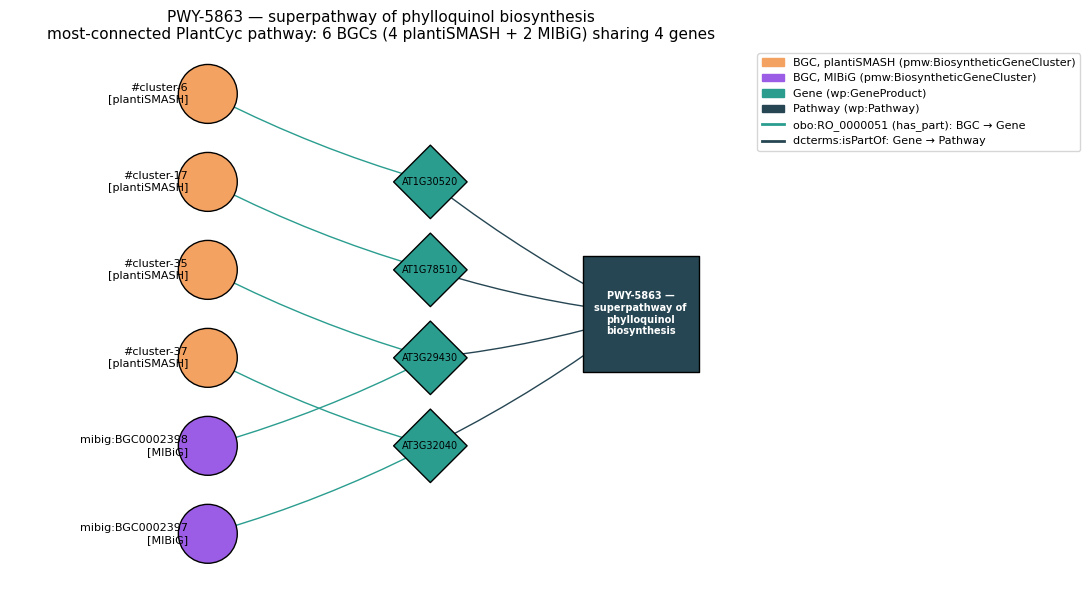

In [19]:
# Network view of the most-connected pathway (by number of distinct BGCs)
top_pw_id, top_pw_title = top_pw_df.iloc[0][["pw_id", "pw_title"]]
# top_pw_uri is the pathway URI (used in cell 31 to query gene totals without relying on
# the internal dcterms:identifier in G_PW, which differs from the PWY ID in G_PROPS)
top_pw_uri = df_links[df_links["pw_id"] == top_pw_id]["pw"].iloc[0]
pc = df_links[df_links["pw_id"] == top_pw_id]

n_ps_bgcs  = pc[pc["source"] == "plantiSMASH"]["bgc_label"].nunique()
n_mib_bgcs = pc[pc["source"] == "MIBiG"]["bgc_label"].nunique()

G = nx.DiGraph()
pw_node = "\n".join(textwrap.wrap(f"{top_pw_id} — {top_pw_title}", 16))
G.add_node(pw_node, kind="Pathway")

bgc_nodes = {}
gene_nodes = set()
for _, row in pc.iterrows():
    bgc_node = f"{row['bgc_label']}\n[{row['source']}]"
    bgc_nodes[row["bgc_label"]] = bgc_node
    G.add_node(bgc_node, kind="BGC", source=row["source"])
    G.add_node(row["gene_id"], kind="Gene")
    gene_nodes.add(row["gene_id"])
    G.add_edge(bgc_node, row["gene_id"], predicate="RO:0000051 (has_part)")
    G.add_edge(row["gene_id"], pw_node, predicate="dcterms:isPartOf")

# manual layered layout: BGCs (left) -> genes (middle) -> pathway (right)
pos = {}
bgc_list = list(bgc_nodes.values())
gene_list = sorted(gene_nodes)
for i, n in enumerate(bgc_list):
    pos[n] = (0, (len(bgc_list) - 1) / 2 - i)
for i, n in enumerate(gene_list):
    pos[n] = (1.8, (len(gene_list) - 1) / 2 - i)
pos[pw_node] = (3.5, 0)

fig, ax = plt.subplots(figsize=(11, 6))
color_map = {"plantiSMASH": "#f4a261", "MIBiG": "#9b5de5"}

for kind, shape, size in [("BGC", "o", 1800), ("Gene", "D", 1400), ("Pathway", "s", 7000)]:
    nodes = [n for n, d in G.nodes(data=True) if d["kind"] == kind]
    if kind == "BGC":
        colors = [color_map[G.nodes[n]["source"]] for n in nodes]
    elif kind == "Gene":
        colors = ["#2a9d8f"] * len(nodes)
    else:
        colors = ["#264653"] * len(nodes)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_shape=shape,
                            node_color=colors, node_size=size, ax=ax,
                            edgecolors="black", linewidths=1)

edges_part   = [(u, v) for u, v, d in G.edges(data=True) if d["predicate"].startswith("RO")]
edges_ispart = [(u, v) for u, v, d in G.edges(data=True) if d["predicate"].startswith("dcterms")]
nx.draw_networkx_edges(G, pos, edgelist=edges_part, edge_color="#2a9d8f", ax=ax,
                        arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_edges(G, pos, edgelist=edges_ispart, edge_color="#264653", ax=ax,
                        arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.05")

# labels: BGCs to the left of node, genes inside diamond, pathway centered in box
for n, (x, y) in pos.items():
    if G.nodes[n]["kind"] == "BGC":
        ax.text(x - 0.16, y, n, ha="right", va="center", fontsize=8)
    elif G.nodes[n]["kind"] == "Gene":
        ax.text(x, y, n, ha="center", va="center", fontsize=7)
    else:
        ax.text(x, y, n, ha="center", va="center", fontsize=7, color="white", fontweight="bold")

legend_handles = [
    mpatches.Patch(color="#f4a261", label="BGC, plantiSMASH (pmw:BiosyntheticGeneCluster)"),
    mpatches.Patch(color="#9b5de5", label="BGC, MIBiG (pmw:BiosyntheticGeneCluster)"),
    mpatches.Patch(color="#2a9d8f", label="Gene (wp:GeneProduct)"),
    mpatches.Patch(color="#264653", label="Pathway (wp:Pathway)"),
    plt.Line2D([0], [0], color="#2a9d8f", lw=2, label="obo:RO_0000051 (has_part): BGC → Gene"),
    plt.Line2D([0], [0], color="#264653", lw=2, label="dcterms:isPartOf: Gene → Pathway"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_title(
    f"{top_pw_id} — {top_pw_title}\n"
    f"most-connected PlantCyc pathway: {pc['bgc_label'].nunique()} BGCs "
    f"({n_ps_bgcs} plantiSMASH + {n_mib_bgcs} MIBiG) sharing {pc['gene_id'].nunique()} genes",
    fontsize=11,
)
ax.set_xlim(-1.6, 4.4)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / f"bgc_network_{top_pw_id}.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / f"bgc_network_{top_pw_id}.svg", bbox_inches="tight")
plt.show()

In [20]:
display(Markdown(
    f"**Figure 7.3.** RDF network of the most-connected PlantCyc pathway "
    f"({top_pw_id} — *{top_pw_title}*), showing all Biosynthetic Gene Clusters linked "
    f"to it via shared `wp:GeneProduct` gene members. "
    f"Circles (left) represent BGCs (`pmw:BiosyntheticGeneCluster`), coloured by source: "
    f"plantiSMASH (orange, *n* = {n_ps_bgcs}) and MIBiG (purple, *n* = {n_mib_bgcs}). "
    f"Diamonds (centre) represent shared genes (`wp:GeneProduct`, *n* = {pc['gene_id'].nunique()}), "
    f"labelled by their TAIR locus identifier. "
    f"The square (right) represents the PlantCyc pathway (`wp:Pathway`). "
    f"Green edges: `obo:RO_0000051` (has_part, BGC → gene); "
    f"dark edges: `dcterms:isPartOf` (gene → pathway). "
    f"This tripartite layout illustrates the SPARQL join mechanism between `graph/bgc-*` and "
    f"`graph/pathways` via the shared `identifiers.org` IRI space: a gene appearing in both a "
    f"BGC graph and the pathway graph provides the cross-graph link without requiring any "
    f"pre-computed mapping table."
))

**Figure 7.3.** RDF network of the most-connected PlantCyc pathway (PWY-5863 — *superpathway of phylloquinol biosynthesis*), showing all Biosynthetic Gene Clusters linked to it via shared `wp:GeneProduct` gene members. Circles (left) represent BGCs (`pmw:BiosyntheticGeneCluster`), coloured by source: plantiSMASH (orange, *n* = 4) and MIBiG (purple, *n* = 2). Diamonds (centre) represent shared genes (`wp:GeneProduct`, *n* = 4), labelled by their TAIR locus identifier. The square (right) represents the PlantCyc pathway (`wp:Pathway`). Green edges: `obo:RO_0000051` (has_part, BGC → gene); dark edges: `dcterms:isPartOf` (gene → pathway). This tripartite layout illustrates the SPARQL join mechanism between `graph/bgc-*` and `graph/pathways` via the shared `identifiers.org` IRI space: a gene appearing in both a BGC graph and the pathway graph provides the cross-graph link without requiring any pre-computed mapping table.

**How many genes does this pathway have in total?**

The network above shows only the genes *shared with BGCs*. The query below counts the full
`wp:GeneProduct` complement of the top-connected pathway in `graph/pathways`, for context.


In [21]:
# Total wp:GeneProduct gene complement of the top-connected pathway, vs. genes shared with BGCs.
# Uses the pathway URI directly (top_pw_uri) because G_PW stores internal PC-sequential IDs
# as dcterms:identifier, not the PWY accession now held in top_pw_id.
df_pw_genes = run_query(f"""
SELECT (COUNT(DISTINCT ?gene) AS ?n_genes_total)
WHERE {{
  GRAPH <{G_PW}> {{
    ?gene dcterms:isPartOf <{top_pw_uri}> ; a wp:GeneProduct .
  }}
}}
""")
n_pw_genes_total = int(df_pw_genes["n_genes_total"].iloc[0])
n_pw_genes_bgc   = pc["gene_id"].nunique()

print(f"{top_pw_id} - {top_pw_title}")
print(f"  Total wp:GeneProduct genes in this pathway (graph/pathways) : {n_pw_genes_total}")
print(f"  Of these, also present in a BGC (plantiSMASH or MIBiG)      : {n_pw_genes_bgc} ({100*n_pw_genes_bgc/n_pw_genes_total:.0f}%)")

PWY-5863 - superpathway of phylloquinol biosynthesis
  Total wp:GeneProduct genes in this pathway (graph/pathways) : 23
  Of these, also present in a BGC (plantiSMASH or MIBiG)      : 4 (17%)


---
## Summary

### Key numbers — BGC graphs in PlantMetWiki (current release)

| | plantiSMASH | MIBiG | Total |
|---|---|---|---|
| Named graph triples | 6,030 | 1,813 | 7,843 |
| BGCs | 65 | 43 | 108 |
| &nbsp;&nbsp;*Arabidopsis thaliana* | 65 | 9 | 74 |
| &nbsp;&nbsp;other / unannotated | 0 | 34 | 34 |
| Gene members (`wp:GeneProduct`) | 940 | 69 | 966 unique |
| Alt. identifiers (`pmw:MemberIdentifier`) | 0 | 403 | 403 |
| Genes shared between plantiSMASH and MIBiG | — | — | 43 |
| **BGCs connected to ≥1 PlantCyc pathway** | **38 / 65 (58%)** | **6 / 43 (14%)** | **44 / 108 (41%)** |
| **BGCs with NO pathway connection** | **27 / 65 (42%)** | **37 / 43 (86%)** | **64 / 108 (59%)** |
| Unique (BGC, gene, pathway) links | 206 | 19 | 225 |
| Unique (BGC, gene) pairs → pathway | 57 | 9 | 66 |
| Unique pathways with ≥1 BGC gene | 131 | 11 | 132 |

### Summary paragraph

> The map-to-rdf current release adds **7,843 triples** to PlantMetWiki across two named graphs:
> `graph/bgc-plantismash` (**6,030 triples**, **65** *Arabidopsis thaliana* BGCs predicted by plantiSMASH v2)
> and `graph/bgc-mibig` (**1,813 triples**, **43** curated MIBiG 4.0 BGCs, **9** of which are annotated as
> *A. thaliana* and **34** without a species annotation). Of these **108 BGCs**, **44** (**38 plantiSMASH +
> 6 MIBiG**) share at least one gene (`wp:GeneProduct`, `identifiers.org` IRI) with a PlantCyc pathway in
> `graph/pathways`, producing **225 unique (BGC, gene, pathway) crosslinks** (Supplementary Table S3 —
> Notebook 7) that involve **66 unique (BGC, gene) pairs**, **58 unique genes**, and **132 unique pathways**.
> The remaining **64 BGCs (27 plantiSMASH + 37 MIBiG, 59% of all BGCs)** currently have **no PlantCyc
> pathway connection**, highlighting potential targets for future pathway annotation.

### Answers to the four questions

1. **How many unique BGC–pathway gene links are there?**
   **225** unique `(BGC, gene, pathway)` triples (206 from plantiSMASH, 19 from MIBiG) — see Section 4 and
   Supplementary Table S3 (Section 4b). Note this is higher than the 199 in the static
   `bgc_pathway_links.tsv`, purely due to a newer `graph/pathways` snapshot (see version note in 4b).

2. **How many BGCs from MIBiG and plantiSMASH are involved?**
   **44 of 108 BGCs total** connect to ≥1 PlantCyc pathway: **38/65 plantiSMASH** and **6/43 MIBiG**.
   The remaining **64/108 (59%)** do not connect to any pathway (27 plantiSMASH, 37 MIBiG).

3. **How many genes and pathways are involved?**
   **58 unique genes** and **132 unique pathways** participate in the 225 crosslinks (66 unique
   `(BGC, gene)` pairs → pathway).

4. **Triple contributions per source, and annotation potential** (see TL;DR at the top of the notebook):
   **plantiSMASH = 6,030** / **MIBiG = 1,813** / **total = 7,843** triples. **64/108 (59%)** of all BGCs
   (27 plantiSMASH + 37 MIBiG) have no PlantCyc pathway connection — these are the clearest candidates
   for future pathway annotation.

**Interpretation:**
- The majority of BGCs (59%) do not yet share any gene with a current PlantCyc pathway, reflecting the
  broader metabolic space that BGC data could help annotate.
- plantiSMASH covers genome-scale predictions for *A. thaliana* (65 BGCs, all connected at the gene level
  to `graph/pathways`); MIBiG provides curated records of known plant BGCs, most without `identifiers.org`
  gene IRIs (hence no pathway join for 37/43 MIBiG BGCs).
- The 132 pathways linked to BGC genes are enriched in specialised metabolism: flavonoid/flavonol pathways,
  terpenoid pathways (e.g. phylloquinol, geranylgeranyl pyrophosphate, plaunotol, taxadiene, thalianol), and
  glucosinolate biosynthesis. The most-connected pathway (Section 7.3) links **6 BGCs (4 plantiSMASH + 2
  MIBiG)** through **4 shared genes**, illustrating how independently-predicted/curated BGCs converge on the
  same PlantCyc pathway.

---
## Sandbox

Write new queries here. Use named graphs explicitly. When a query is validated, add it to **[SPARQLQueries](https://github.com/pathway-lod/SPARQLQueries)**.

In [22]:
run_query(f"""
SELECT *
WHERE {{
  # ← write your query here
}}
LIMIT 20
""")

,_star_fake
0,1
